## Inicialización

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## Cargar datos

In [2]:
users = pd.read_csv('/datasets/megaline_users.csv')
calls = pd.read_csv('/datasets/megaline_calls.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
tariffs = pd.read_csv('/datasets/megaline_plans.csv')

## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

## Tarifas

In [3]:
tariffs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
tariffs.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [5]:
tariffs.describe()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
count,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000
mean,525.000000,23040.000000,1750.000000,45.000000,8.50000,0.020000,0.020000
std,671.751442,10861.160159,1767.766953,35.355339,2.12132,0.014142,0.014142
min,50.000000,15360.000000,500.000000,20.000000,7.00000,0.010000,0.010000
25%,287.500000,19200.000000,1125.000000,32.500000,7.75000,0.015000,0.015000
50%,525.000000,23040.000000,1750.000000,45.000000,8.50000,0.020000,0.020000
75%,762.500000,26880.000000,2375.000000,57.500000,9.25000,0.025000,0.025000
max,1000.000000,30720.000000,3000.000000,70.000000,10.00000,0.030000,0.030000


## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

## Usuarios/as

In [6]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [7]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [8]:
users.reg_date = pd.to_datetime(users.reg_date)

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [9]:
users['months'] = users.reg_date.dt.month

In [10]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,months
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN,12
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,8
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN,10
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN,1
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN,5


## Llamadas

In [11]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [12]:
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [13]:
calls.call_date = pd.to_datetime(calls.call_date)

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [14]:
calls['months'] = calls.call_date.dt.month

In [15]:
calls.head()

,id,user_id,call_date,duration,months
0,1000_93,1000,2018-12-27,8.52,12
1,1000_145,1000,2018-12-27,13.66,12
2,1000_247,1000,2018-12-27,14.48,12
3,1000_309,1000,2018-12-28,5.76,12
4,1000_380,1000,2018-12-30,4.22,12


## Mensajes

In [16]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [17]:
messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [18]:
messages.message_date = pd.to_datetime(messages.message_date)

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [19]:
messages['months'] = messages.message_date.dt.month

In [20]:
messages.head()

,id,user_id,message_date,months
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12


## Internet

In [21]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [22]:
internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [23]:
internet.session_date = pd.to_datetime(internet.session_date)

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [24]:
internet['months'] = internet.session_date.dt.month

In [25]:
internet.head()

,id,user_id,session_date,mb_used,months
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12


## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [26]:
display(tariffs)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [27]:
calls['month'] = calls['call_date'].dt.month
messages['month'] = messages['message_date'].dt.month
internet['month'] = internet['session_date'].dt.month

In [28]:
calls_per_month = (
    calls.groupby(['user_id', 'month'])
    .agg(
        calls_count=('id', 'count'),  
        minutes=('duration', 'sum') 
    )
    .reset_index()
)

In [29]:
messages_per_month = (
    messages.groupby(['user_id', 'month'])
    .agg(
        messages_count=('id', 'count')
    )
    .reset_index()
)

In [30]:
internet_per_month = (
    internet.groupby(['user_id', 'month'])
    .agg(
        mb_used=('mb_used', 'sum')  
    )
    .reset_index()
)

[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [31]:
data = (users
    .merge(calls_per_month, on='user_id', how='left')
    .merge(messages_per_month, on=['user_id', 'month'], how='left')
    .merge(internet_per_month, on=['user_id', 'month'], how='left')
)

In [32]:
data = data.fillna(0)

[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [33]:
display(data.head())
data.info()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,months,month,calls_count,minutes,messages_count,mb_used
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,0,12,12.0,16.0,116.83,11.0,1901.47
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,8,8.0,27.0,171.14,30.0,6919.15
2,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,8,9.0,49.0,297.69,44.0,13314.82
3,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,8,10.0,65.0,374.11,53.0,22330.49
4,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,8,11.0,64.0,404.59,36.0,18504.30


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2277 entries, 0 to 2276
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         2277 non-null   int64         
 1   first_name      2277 non-null   object        
 2   last_name       2277 non-null   object        
 3   age             2277 non-null   int64         
 4   city            2277 non-null   object        
 5   reg_date        2277 non-null   datetime64[ns]
 6   plan            2277 non-null   object        
 7   churn_date      2277 non-null   object        
 8   months          2277 non-null   int64         
 9   month           2277 non-null   float64       
 10  calls_count     2277 non-null   float64       
 11  minutes         2277 non-null   float64       
 12  messages_count  2277 non-null   float64       
 13  mb_used         2277 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(3), object(5)
me

## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
calls_stats = data.groupby('plan')['minutes'].agg(['mean', 'median', 'std', 'min', 'max'])
display(calls_stats)

,mean,median,std,min,max
plan,,,,,
surf,408.659332,404.0,219.123079,0.0,1431.22
ultimate,406.758025,398.6,226.898171,0.0,1292.09


[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

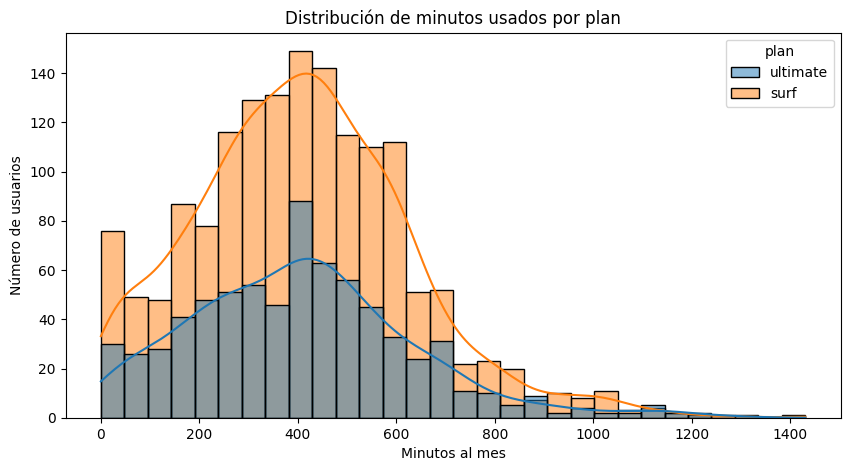

In [36]:
plt.figure(figsize=(10,5))
sns.histplot(data=data, x='minutes', hue='plan', kde=True, bins=30)
plt.title('Distribución de minutos usados por plan')
plt.xlabel('Minutos al mes')
plt.ylabel('Número de usuarios')
plt.show()

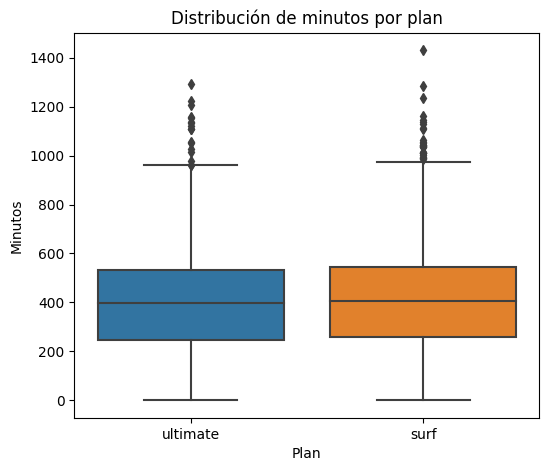

In [37]:
plt.figure(figsize=(6,5))
sns.boxplot(data=data, x='plan', y='minutes')
plt.title('Distribución de minutos por plan')
plt.xlabel('Plan')
plt.ylabel('Minutos')
plt.show()

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

### Mensajes

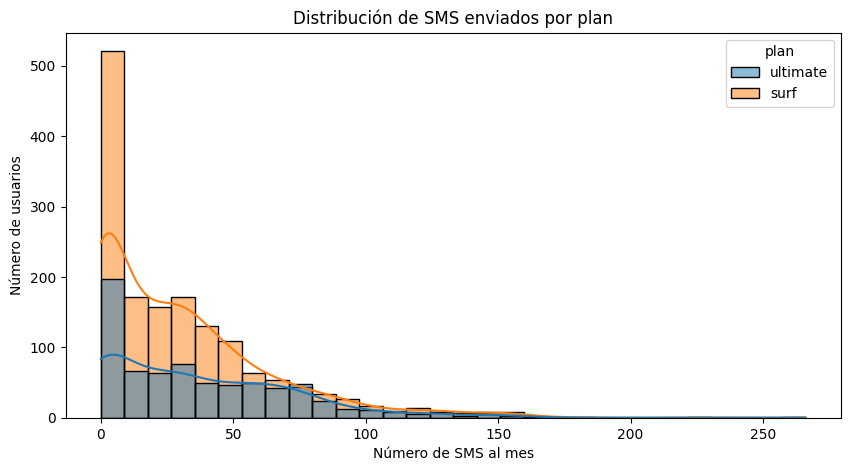

In [38]:
plt.figure(figsize=(10,5))
sns.histplot(data=data, x='messages_count', hue='plan', kde=True, bins=30)
plt.title('Distribución de SMS enviados por plan')
plt.xlabel('Número de SMS al mes')
plt.ylabel('Número de usuarios')
plt.show()

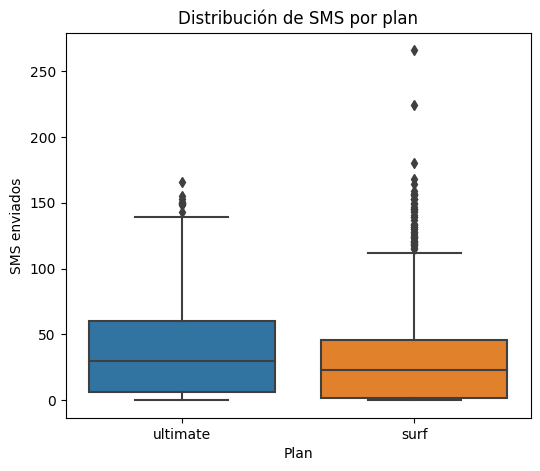

In [39]:
plt.figure(figsize=(6,5))
sns.boxplot(data=data, x='plan', y='messages_count')
plt.title('Distribución de SMS por plan')
plt.xlabel('Plan')
plt.ylabel('SMS enviados')
plt.show()

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

### Internet

In [40]:
data['gb_used'] = data['mb_used'] / 1024
internet_stats = data.groupby('plan')['gb_used'].agg(['mean', 'median', 'std', 'min', 'max'])
display(internet_stats)

,mean,median,std,min,max
plan,,,,,
surf,15.984378,16.401870,7.771481,0.0,69.269131
ultimate,16.732246,16.404199,7.700797,0.0,45.503252


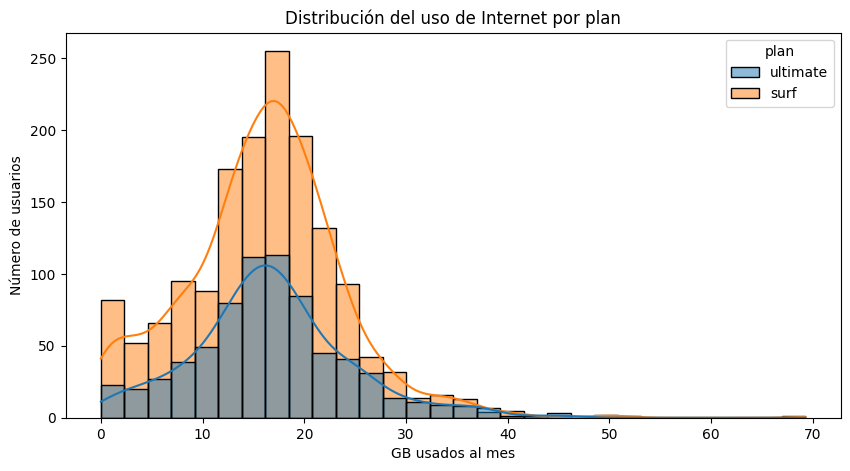

In [41]:
plt.figure(figsize=(10,5))
sns.histplot(data=data, x='gb_used', hue='plan', kde=True, bins=30)
plt.title('Distribución del uso de Internet por plan')
plt.xlabel('GB usados al mes')
plt.ylabel('Número de usuarios')
plt.show()

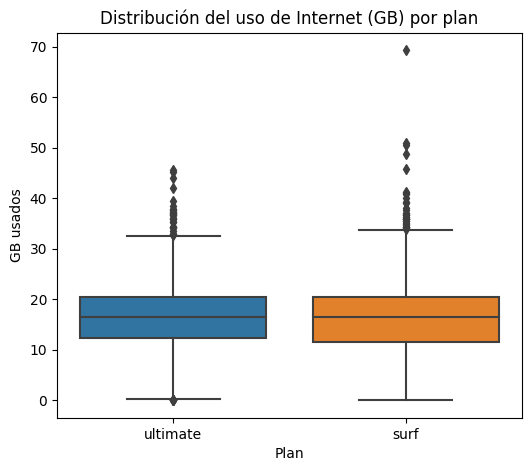

In [42]:
plt.figure(figsize=(6,5))
sns.boxplot(data=data, x='plan', y='gb_used')
plt.title('Distribución del uso de Internet (GB) por plan')
plt.xlabel('Plan')
plt.ylabel('GB usados')
plt.show()

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

In [43]:
def calculate_revenue(row):
    if row['plan'] == 'surf':
        monthly_fee = 20
        min_included = 500
        sms_included = 50
        gb_included = 15
        cost_min = 0.03
        cost_sms = 0.03
        cost_gb = 10
    else:  # ultimate
        monthly_fee = 70
        min_included = 3000
        sms_included = 1000
        gb_included = 30
        cost_min = 0.01
        cost_sms = 0.01
        cost_gb = 7

    # Calcular excedentes
    extra_minutes = max(0, row['minutes'] - min_included)
    extra_sms = max(0, row['messages_count'] - sms_included)
    
    # Convertir MB a GB y calcular excedente (redondeando hacia arriba)
    gb_used = row['mb_used'] / 1024
    extra_gb = max(0, np.ceil(gb_used - gb_included))
    
    # Ingreso total
    revenue = monthly_fee + (extra_minutes * cost_min) + (extra_sms * cost_sms) + (extra_gb * cost_gb)
    return revenue

# Aplicar la función a cada fila
data['revenue'] = data.apply(calculate_revenue, axis=1)

# Revisar los primeros registros
display(data[['user_id', 'month', 'plan', 'revenue']].head())

,user_id,month,plan,revenue
0,1000,12.0,ultimate,70.00
1,1001,8.0,surf,20.00
2,1001,9.0,surf,20.00
3,1001,10.0,surf,90.09
4,1001,11.0,surf,60.00


In [44]:
revenue_stats = data.groupby('plan')['revenue'].agg(['mean', 'median', 'std', 'min', 'max'])
display(revenue_stats)

,mean,median,std,min,max
plan,,,,,
surf,59.407995,40.0,53.296390,20.0,588.6372
ultimate,72.258693,70.0,11.306313,70.0,182.0000


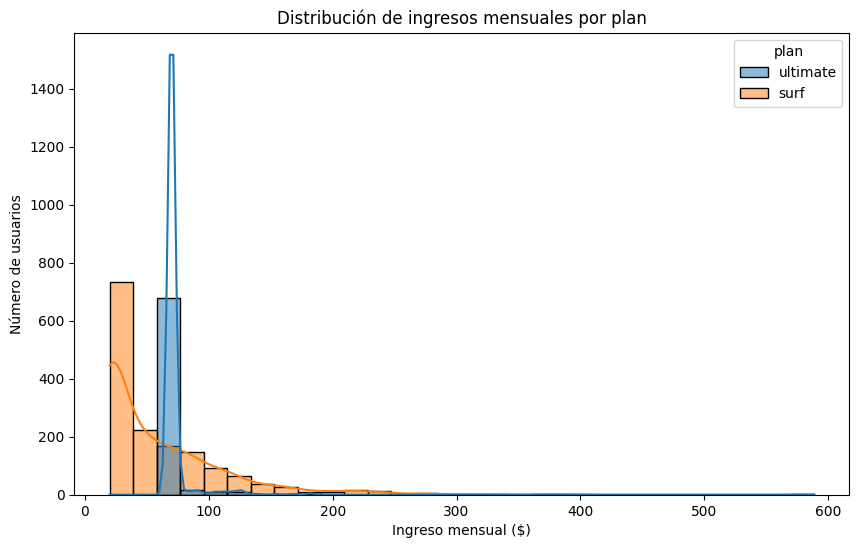

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(data=data, x='revenue', hue='plan', kde=True, bins=30)
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Ingreso mensual ($)')
plt.ylabel('Número de usuarios')
plt.show()

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [46]:


print("Hipótesis Nula (H0): Los ingresos promedio de ambos planes son iguales")
print("Hipótesis Alternativa (H1): Los ingresos promedio de ambos planes son diferentes")



Hipótesis Nula (H0): Los ingresos promedio de ambos planes son iguales
Hipótesis Alternativa (H1): Los ingresos promedio de ambos planes son diferentes


In [47]:

data.query('plan == "surf"')
data_surf = data.query('plan == "surf"')

data.query('plan == "ultimate"')
data_ultimate = data.query('plan == "ultimate"')




In [48]:


from scipy import stats as st

alfa = 0.05 
result = st.ttest_ind(data_surf["revenue"],data_ultimate["revenue"])
if result.pvalue < alfa:
    print("se rechaza la hipotesis nula")
else: 
    print("no se rechaza la hipotesis nula")



se rechaza la hipotesis nula


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [52]:
from scipy import stats as st
data_nynj = data.query('city == "New York-Newark-Jersey City, NY-NJ-PA MSA"')
data_otros = data.query('city != "New York-Newark-Jersey City, NY-NJ-PA MSA"')
alfa = 0.05
result = st.ttest_ind(data_nynj["revenue"], data_otros["revenue"], equal_var=False)
print("Hipótesis Nula (H0): Los ingresos promedio son iguales entre NY-NJ y otras regiones")
print("Hipótesis Alternativa (H1): Los ingresos promedio son diferentes entre NY-NJ y otras regiones")
print(f"Estadístico t: {result.statistic:.4f}")
print(f"Valor p: {result.pvalue:.4f}")
if result.pvalue < alfa:
    print("➡ Se rechaza la hipótesis nula: los ingresos promedio son diferentes.")
else:
    print("➡ No se rechaza la hipótesis nula: no hay diferencias significativas en los ingresos promedio.")
    

Hipótesis Nula (H0): Los ingresos promedio son iguales entre NY-NJ y otras regiones
Hipótesis Alternativa (H1): Los ingresos promedio son diferentes entre NY-NJ y otras regiones
Estadístico t: -2.4507
Valor p: 0.0146
➡ Se rechaza la hipótesis nula: los ingresos promedio son diferentes.


In [53]:
data_nynj

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,months,month,calls_count,minutes,messages_count,mb_used,gb_used,revenue
56,1014,Edmundo,Simon,61,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-25,surf,0,11,11.0,28.0,149.33,9.0,1175.59,1.148037,20.0000
57,1014,Edmundo,Simon,61,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-25,surf,0,11,12.0,150.0,1050.62,64.0,7792.41,7.609775,36.9386
75,1022,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-20,surf,2018-09-07,4,5.0,39.0,287.34,0.0,4908.08,4.793047,20.0000
76,1022,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-20,surf,2018-09-07,4,6.0,76.0,455.45,0.0,23436.48,22.887187,100.0000
77,1022,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-20,surf,2018-09-07,4,7.0,70.0,448.25,0.0,9933.15,9.700342,20.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2268,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,0,2,8.0,44.0,244.57,0.0,20261.89,19.787002,70.0000
2269,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,0,2,9.0,45.0,344.62,0.0,22827.28,22.292266,100.0000
2270,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,0,2,10.0,46.0,278.06,0.0,20580.76,20.098398,80.0000
2271,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,0,2,11.0,41.0,208.99,0.0,19168.55,18.719287,60.0000


## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]